PART 1: Deep Networks on Numeric Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [9]:
N=3000
x1=np.random.uniform(-2,2,N)
x2=np.random.uniform(-2,2,N)

y=(x1**2+x2**2>1.5).astype(int).reshape(-1,1)

X=np.column_stack((x1,x2))

print(X.shape)

(3000, 2)


In [10]:
# train test split
indices=np.random.permutation(N)
train_end=int(0.70*N)
val_end=int(0.85*N)

train_idx=indices[:train_end]
val_idx=indices[train_end:val_end]
test_idx=indices[val_end:]

X_train=X[train_idx]
X_val=X[val_idx]
X_test=X[test_idx]

y_train=y[train_idx]
y_val=y[val_idx]
y_test=y[test_idx]

Task 1A — Build Three Architectures (Dense)

In [11]:
def sigmoid(z):
  z=np.clip(z,-500,500)
  return 1/(1+np.exp(-z))

def relu(z):
  return np.maximum(0,z)

def sigmoid_derivative(z):
  return sigmoid(z)*(1-sigmoid(z))

def relu_derivative(z):
  return (z>0).astype(int)

In [12]:
eps=1e-8

def binary_cross_entropy(y_true,y_pred):
    y_pred=np.clip(y_pred,eps,1-eps)
    return -np.mean(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))

def accuracy(y_true,y_pred):
    return np.mean((y_pred>=0.5)==y_true)

In [13]:
def init_weights(layers):
    params={}
    for i in range(len(layers)-1):
        params[f'W{i+1}']=np.random.randn(layers[i],layers[i+1])*0.1
        params[f'b{i+1}']=np.zeros((1,layers[i+1]))
    return params

def count_parameters(layers):
    total=0
    for i in range(len(layers)-1):
        total+=layers[i]*layers[i+1]+layers[i+1]
    return total

In [14]:
def forward(X,params,activation):
    A=X
    cache={'A0':X}
    L=len(params)//2
    for i in range(1,L+1):
        Z=A@params[f'W{i}']+params[f'b{i}']
        cache[f'Z{i}']=Z
        if i==L:
            A=sigmoid(Z)
        else:
            A=relu(Z) if activation=='relu' else sigmoid(Z)
        cache[f'A{i}']=A
    return A,cache

In [21]:
def backward(y_true,y_pred,params,cache,activation):
    m=y_true.shape[0]
    grads={}
    grad_norms={}
    L=len(params)//2
    dZ=y_pred-y_true
    for i in range(L,0,-1):
        A_prev=cache[f'A{i-1}']
        grads[f'dW{i}']=A_prev.T@dZ/m
        grads[f'db{i}']=np.sum(dZ,axis=0,keepdims=True)/m
        grad_norms[f'layer{i}']=np.linalg.norm(grads[f'dW{i}'])
        if i>1:
            dA=dZ@params[f'W{i}'].T
            Z_prev=cache[f'Z{i-1}']
            if activation=='relu':
                dZ=dA*relu_derivative(Z_prev)
            else:
                dZ=dA*sigmoid_derivative(Z_prev)
    return grads,grad_norms

In [22]:
def update_sgd(params,grads,lr):
    for i in range(1,len(params)//2+1):
        params[f'W{i}']-=lr*grads[f'dW{i}']
        params[f'b{i}']-=lr*grads[f'db{i}']

def update_momentum(params,grads,vel,lr,beta=0.9):
    for i in range(1,len(params)//2+1):
        vel[f'W{i}']=beta*vel[f'W{i}']+lr*grads[f'dW{i}']
        vel[f'b{i}']=beta*vel[f'b{i}']+lr*grads[f'db{i}']
        params[f'W{i}']-=vel[f'W{i}']
        params[f'b{i}']-=vel[f'b{i}']

In [23]:
def train(layers,activation='relu',optimizer='sgd',epochs=500,lr=0.01):
    params=init_weights(layers)
    history={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'grad_norms':[]}
    if optimizer=='momentum':
        vel={}
        for i in range(1,len(layers)):
            vel[f'W{i}']=np.zeros_like(params[f'W{i}'])
            vel[f'b{i}']=np.zeros_like(params[f'b{i}'])
    for epoch in range(epochs):
        y_pred,cache=forward(X_train,params,activation)
        train_loss=binary_cross_entropy(y_train,y_pred)
        train_acc=accuracy(y_train,y_pred)
        y_val_pred,_=forward(X_val,params,activation)
        val_loss=binary_cross_entropy(y_val,y_val_pred)
        val_acc=accuracy(y_val,y_val_pred)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        grads,grad_norms=backward(y_train,y_pred,params,cache,activation)
        history['grad_norms'].append(grad_norms)
        if optimizer=='sgd':
            update_sgd(params,grads,lr)
        else:
            update_momentum(params,grads,vel,lr)
    return params,history

In [24]:
arch_2=[2,4,1]
arch_5=[2,4,4,4,4,1]
arch_10=[2,4,4,4,4,4,4,4,4,4,1]

print("2L params:",count_parameters(arch_2))
print("5L params:",count_parameters(arch_5))
print("10L params:",count_parameters(arch_10))

2L params: 17
5L params: 77
10L params: 177


In [29]:
architectures={
    '2L':[2,4,1],
    '5L':[2,4,4,4,4,1],
    '10L':[2,4,4,4,4,4,4,4,4,4,1]
}

activations=['sigmoid','relu']
optimizers=['sgd','momentum']

results={}

for arch_name,arch in architectures.items():
    print("Architecture:",arch_name)
    print("Parameters:",count_parameters(arch))
    print("-"*40)

    for act in activations:
        for opt in optimizers:

            print(f"Training: {arch_name} | {act} | {opt}")

            params,history=train(arch,activation=act,optimizer=opt,epochs=500,lr=0.01)

            y_train_pred,_=forward(X_train,params,act)
            y_val_pred,_=forward(X_val,params,act)
            y_test_pred,_=forward(X_test,params,act)

            train_acc=accuracy(y_train,y_train_pred)
            val_acc=accuracy(y_val,y_val_pred)
            test_acc=accuracy(y_test,y_test_pred)

            train_loss=binary_cross_entropy(y_train,y_train_pred)
            val_loss=binary_cross_entropy(y_val,y_val_pred)
            test_loss=binary_cross_entropy(y_test,y_test_pred)

            print("Train Acc:",train_acc)
            print("Val Acc:",val_acc)
            print("Train Loss:",train_loss)
            print("Val Loss:",val_loss)
            print()

            results[(arch_name,act,opt)]={
                'params':params,
                'history':history,
                'train_acc':train_acc,
                'val_acc':val_acc,
                'test_acc':test_acc
            }

Architecture: 2L
Parameters: 17
----------------------------------------
Training: 2L | sigmoid | sgd
Train Acc: 0.6971428571428572
Val Acc: 0.7444444444444445
Train Loss: 0.6144606459945672
Val Loss: 0.5791183481360531

Training: 2L | sigmoid | momentum
Train Acc: 0.6971428571428572
Val Acc: 0.7444444444444445
Train Loss: 0.6132977211116839
Val Loss: 0.5740364404032336

Training: 2L | relu | sgd
Train Acc: 0.6971428571428572
Val Acc: 0.7444444444444445
Train Loss: 0.6180137694814388
Val Loss: 0.5910321461359773

Training: 2L | relu | momentum
Train Acc: 0.6971428571428572
Val Acc: 0.7444444444444445
Train Loss: 0.5492184911467433
Val Loss: 0.5130788079826843

Architecture: 5L
Parameters: 77
----------------------------------------
Training: 5L | sigmoid | sgd
Train Acc: 0.6971428571428572
Val Acc: 0.7444444444444445
Train Loss: 0.6141375371166133
Val Loss: 0.5789743397029757

Training: 5L | sigmoid | momentum
Train Acc: 0.6971428571428572
Val Acc: 0.7444444444444445
Train Loss: 0.6132

In [30]:
print(f"{'Model':<8}{'Depth':<8}{'Act':<10}{'Opt':<10}{'Params':<10}{'TrainAcc':<12}{'ValAcc':<12}{'TestAcc':<12}")
print("-"*90)

for (arch_name,act,opt),data in results.items():
    depth=int(arch_name.replace('L',''))
    params_count=count_parameters(architectures[arch_name])
    print(f"{arch_name:<8}{depth:<8}{act:<10}{opt:<10}{params_count:<10}{data['train_acc']:<12.4f}{data['val_acc']:<12.4f}{data['test_acc']:<12.4f}")

Model   Depth   Act       Opt       Params    TrainAcc    ValAcc      TestAcc     
------------------------------------------------------------------------------------------
2L      2       sigmoid   sgd       17        0.6971      0.7444      0.7156      
2L      2       sigmoid   momentum  17        0.6971      0.7444      0.7156      
2L      2       relu      sgd       17        0.6971      0.7444      0.7156      
2L      2       relu      momentum  17        0.6971      0.7444      0.7156      
5L      5       sigmoid   sgd       77        0.6971      0.7444      0.7156      
5L      5       sigmoid   momentum  77        0.6971      0.7444      0.7156      
5L      5       relu      sgd       77        0.6971      0.7444      0.7156      
5L      5       relu      momentum  77        0.6971      0.7444      0.7156      
10L     10      sigmoid   sgd       177       0.6971      0.7444      0.7156      
10L     10      sigmoid   momentum  177       0.6971      0.7444      0.7156   

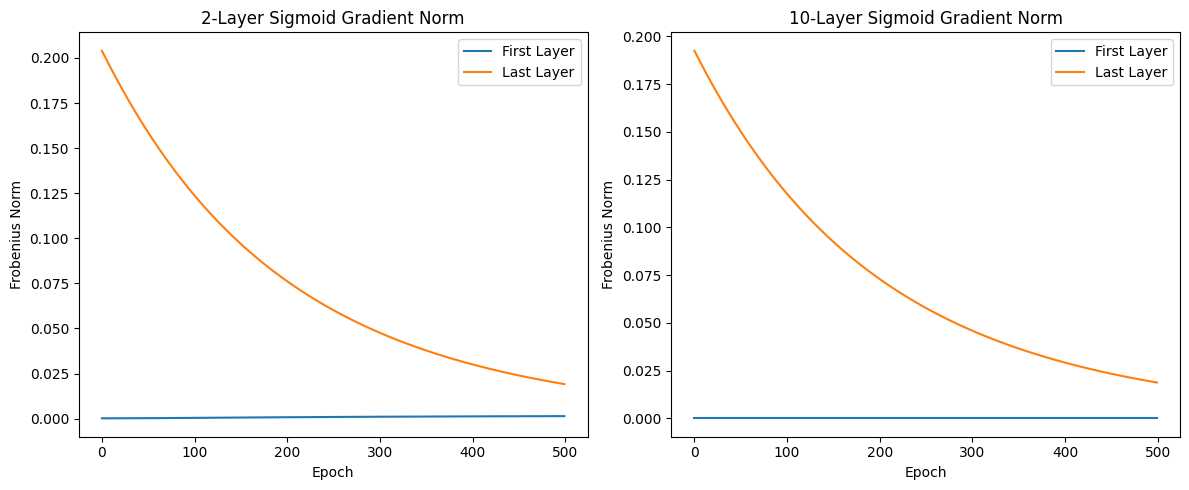

In [34]:
hist_2L_sig = results[('2L','sigmoid','sgd')]['history']
hist_10L_sig = results[('10L','sigmoid','sgd')]['history']

grad_2L_first = [g['layer1'] for g in hist_2L_sig['grad_norms']]
grad_2L_last  = [g['layer2'] for g in hist_2L_sig['grad_norms']]

grad_10L_first = [g['layer1'] for g in hist_10L_sig['grad_norms']]
grad_10L_last  = [g[f'layer{len(architectures["10L"])-1}'] for g in hist_10L_sig['grad_norms']]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(grad_2L_first,label='First Layer')
plt.plot(grad_2L_last,label='Last Layer')
plt.title('2-Layer Sigmoid Gradient Norm')
plt.xlabel('Epoch')
plt.ylabel('Frobenius Norm')
plt.legend()

plt.subplot(1,2,2)
plt.plot(grad_10L_first,label='First Layer')
plt.plot(grad_10L_last,label='Last Layer')
plt.title('10-Layer Sigmoid Gradient Norm')
plt.xlabel('Epoch')
plt.ylabel('Frobenius Norm')
plt.legend()

plt.tight_layout()
plt.show()

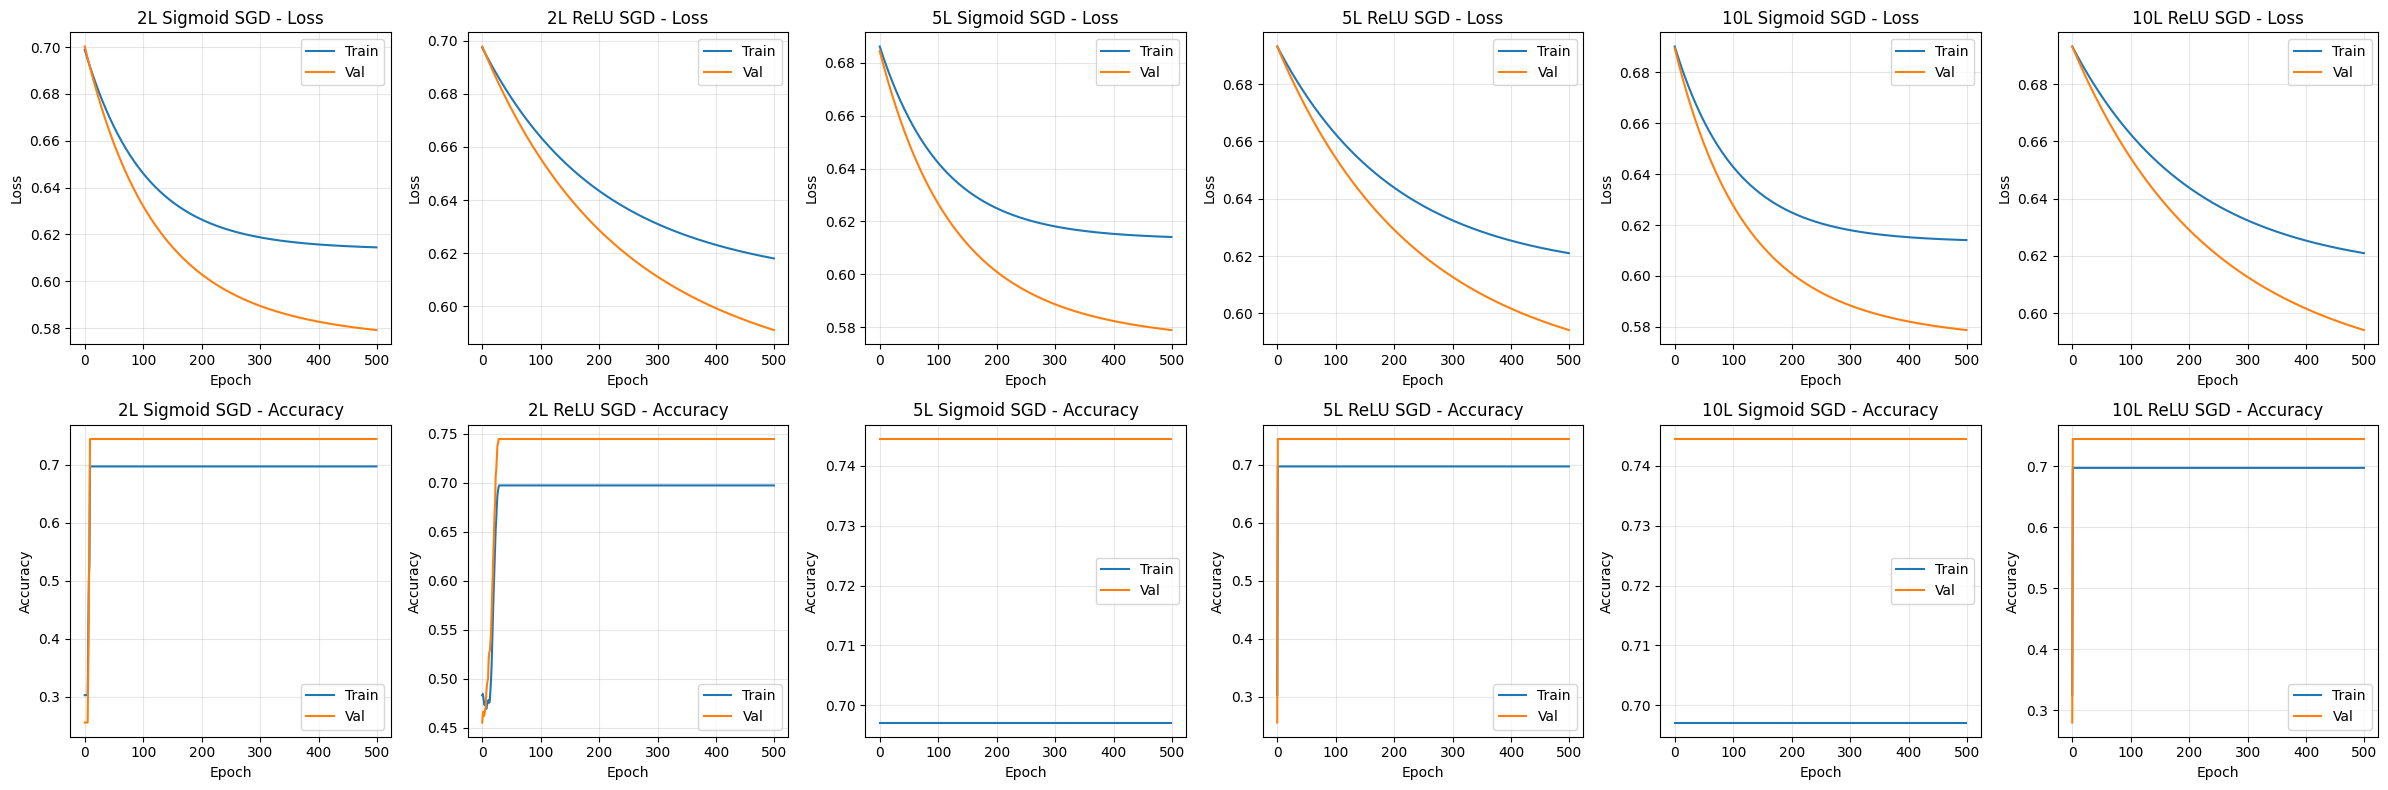

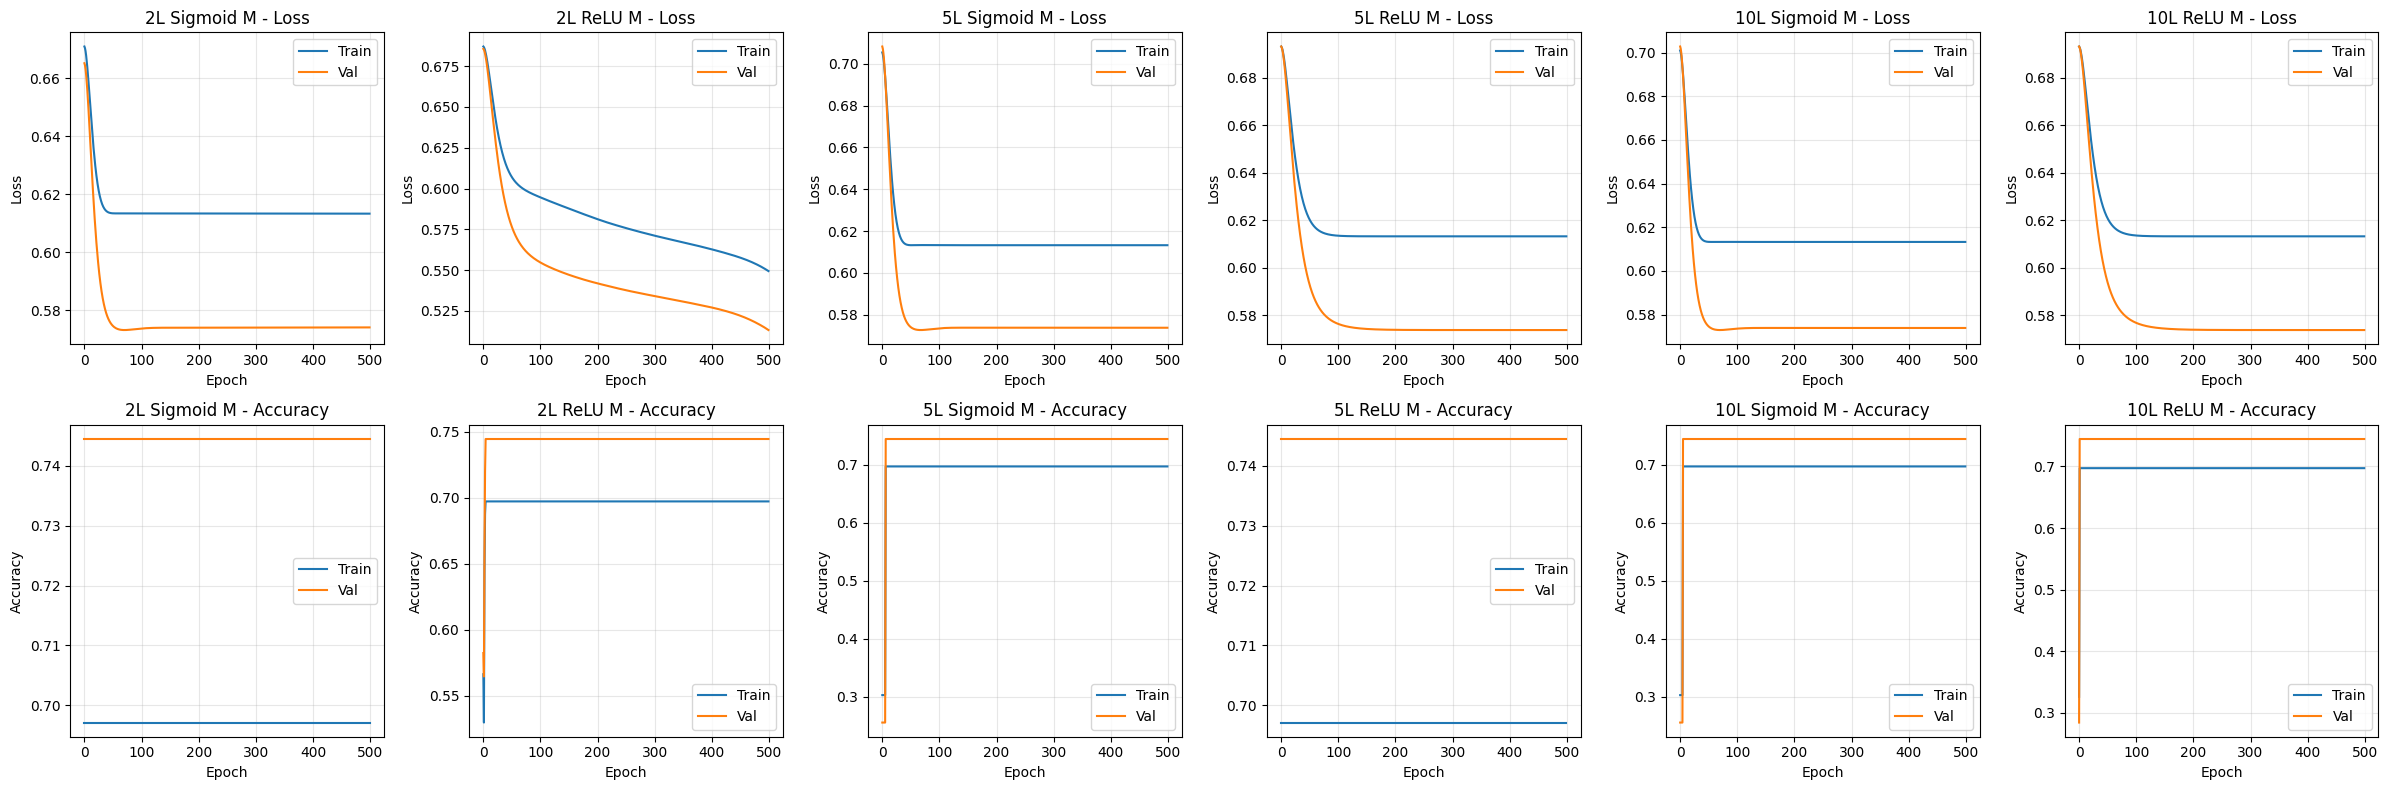

In [35]:
fig,axes=plt.subplots(2,6,figsize=(24,8))

models=[
('2L Sigmoid SGD',results[('2L','sigmoid','sgd')]['history']),
('2L ReLU SGD',results[('2L','relu','sgd')]['history']),
('5L Sigmoid SGD',results[('5L','sigmoid','sgd')]['history']),
('5L ReLU SGD',results[('5L','relu','sgd')]['history']),
('10L Sigmoid SGD',results[('10L','sigmoid','sgd')]['history']),
('10L ReLU SGD',results[('10L','relu','sgd')]['history']),
('2L Sigmoid M',results[('2L','sigmoid','momentum')]['history']),
('2L ReLU M',results[('2L','relu','momentum')]['history']),
('5L Sigmoid M',results[('5L','sigmoid','momentum')]['history']),
('5L ReLU M',results[('5L','relu','momentum')]['history']),
('10L Sigmoid M',results[('10L','sigmoid','momentum')]['history']),
('10L ReLU M',results[('10L','relu','momentum')]['history'])
]

for i,(name,hist) in enumerate(models[:6]):
    axes[0,i].plot(hist['train_loss'],label='Train')
    axes[0,i].plot(hist['val_loss'],label='Val')
    axes[0,i].set_title(f'{name} - Loss')
    axes[0,i].set_xlabel('Epoch')
    axes[0,i].set_ylabel('Loss')
    axes[0,i].legend()
    axes[0,i].grid(True,alpha=0.3)

for i,(name,hist) in enumerate(models[:6]):
    axes[1,i].plot(hist['train_acc'],label='Train')
    axes[1,i].plot(hist['val_acc'],label='Val')
    axes[1,i].set_title(f'{name} - Accuracy')
    axes[1,i].set_xlabel('Epoch')
    axes[1,i].set_ylabel('Accuracy')
    axes[1,i].legend()
    axes[1,i].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

fig,axes=plt.subplots(2,6,figsize=(24,8))

for i,(name,hist) in enumerate(models[6:]):
    axes[0,i].plot(hist['train_loss'],label='Train')
    axes[0,i].plot(hist['val_loss'],label='Val')
    axes[0,i].set_title(f'{name} - Loss')
    axes[0,i].set_xlabel('Epoch')
    axes[0,i].set_ylabel('Loss')
    axes[0,i].legend()
    axes[0,i].grid(True,alpha=0.3)

for i,(name,hist) in enumerate(models[6:]):
    axes[1,i].plot(hist['train_acc'],label='Train')
    axes[1,i].plot(hist['val_acc'],label='Val')
    axes[1,i].set_title(f'{name} - Accuracy')
    axes[1,i].set_xlabel('Epoch')
    axes[1,i].set_ylabel('Accuracy')
    axes[1,i].legend()
    axes[1,i].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

PART 2 — From Dense to Convolution

In [36]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

N=3000
img_size=8
sigma=0.1

X=np.zeros((N,img_size,img_size))
y=np.zeros((N,1))

for i in range(N):
    img=np.zeros((img_size,img_size))
    if i<N//2:
        img[:,img_size//2]=1
        y[i]=0
    else:
        img[img_size//2,:]=1
        y[i]=1
    img+=np.random.normal(0,sigma,(img_size,img_size))
    X[i]=img

idx=np.random.permutation(N)
tr=int(0.7*N);va=int(0.85*N)
X_train,X_val,X_test=X[idx[:tr]],X[idx[tr:va]],X[idx[va:]]
y_train,y_val,y_test=y[idx[:tr]],y[idx[tr:va]],y[idx[va:]]

In [37]:
def sigmoid(z):
    z=np.clip(z,-500,500)
    return 1/(1+np.exp(-z))

def relu(z):
    return np.maximum(0,z)

def relu_d(z):
    return (z>0).astype(float)

def bce(y,yh):
    eps=1e-8
    yh=np.clip(yh,eps,1-eps)
    return -np.mean(y*np.log(yh)+(1-y)*np.log(1-yh))

def acc(y,yh):
    return np.mean((yh>=0.5)==y)

In [38]:
Xtr_flat=X_train.reshape(len(X_train),-1)
Xva_flat=X_val.reshape(len(X_val),-1)
Xte_flat=X_test.reshape(len(X_test),-1)

input_size=64
hidden=32

W1=np.random.randn(input_size,hidden)*0.1
b1=np.zeros((1,hidden))
W2=np.random.randn(hidden,1)*0.1
b2=np.zeros((1,1))

lr=0.01
epochs=200

hist_dense={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}

for e in range(epochs):
    Z1=Xtr_flat@W1+b1
    A1=relu(Z1)
    Z2=A1@W2+b2
    A2=sigmoid(Z2)

    loss=bce(y_train,A2)
    hist_dense['train_loss'].append(loss)
    hist_dense['train_acc'].append(acc(y_train,A2))

    Z1v=Xva_flat@W1+b1
    A1v=relu(Z1v)
    Z2v=A1v@W2+b2
    A2v=sigmoid(Z2v)

    hist_dense['val_loss'].append(bce(y_val,A2v))
    hist_dense['val_acc'].append(acc(y_val,A2v))

    dZ2=A2-y_train
    dW2=A1.T@dZ2/len(Xtr_flat)
    db2=np.mean(dZ2,axis=0,keepdims=True)

    dA1=dZ2@W2.T
    dZ1=dA1*relu_d(Z1)
    dW1=Xtr_flat.T@dZ1/len(Xtr_flat)
    db1=np.mean(dZ1,axis=0,keepdims=True)

    W2-=lr*dW2; b2-=lr*db2
    W1-=lr*dW1; b1-=lr*db1

print("Dense Train Acc:",hist_dense['train_acc'][-1])
print("Dense Val Acc:",hist_dense['val_acc'][-1])

Dense Train Acc: 1.0
Dense Val Acc: 1.0


In [41]:
F=3
num_filters=4

K=np.random.randn(num_filters,F,F)*0.1
b_conv=np.zeros((num_filters,1))

W_dense=np.random.randn(num_filters*3*3,1)*0.1
b_dense=np.zeros((1,1))

def conv_forward(X,K):
    N,H,W=X.shape
    F=K.shape[1]
    out=np.zeros((N,num_filters,H-F+1,W-F+1))
    for n in range(N):
        for f in range(num_filters):
            for i in range(H-F+1):
                for j in range(W-F+1):
                    region=X[n,i:i+F,j:j+F]
                    out[n,f,i,j]=np.sum(region*K[f])
    return out

def pool_forward(X):
    N,C,H,W=X.shape
    out=np.zeros((N,C,H//2,W//2))
    for n in range(N):
        for c in range(C):
            for i in range(0,H,2):
                for j in range(0,W,2):
                    out[n,c,i//2,j//2]=np.max(X[n,c,i:i+2,j:j+2])
    return out

lr=0.01
epochs=100
hist_cnn={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}

for e in range(epochs):
    conv=conv_forward(X_train,K)
    rel=relu(conv)
    pool=pool_forward(rel)
    flat=pool.reshape(len(pool),-1)
    Z=flat@W_dense+b_dense
    A=sigmoid(Z)

    hist_cnn['train_loss'].append(bce(y_train,A))
    hist_cnn['train_acc'].append(acc(y_train,A))

    conv_v=conv_forward(X_val,K)
    rel_v=relu(conv_v)
    pool_v=pool_forward(rel_v)
    flat_v=pool_v.reshape(len(pool_v),-1)
    A_v=sigmoid(flat_v@W_dense+b_dense)

    hist_cnn['val_loss'].append(bce(y_val,A_v))
    hist_cnn['val_acc'].append(acc(y_val,A_v))

print("CNN Train Acc:",hist_cnn['train_acc'][-1])
print("CNN Val Acc:",hist_cnn['val_acc'][-1])

CNN Train Acc: 0.9980952380952381
CNN Val Acc: 1.0


In [42]:
dense_params=input_size*hidden+hidden+hidden*1+1
cnn_params=(F*F*1)*num_filters + (num_filters*6*6)*1 + 1
print("Dense Params:",dense_params)
print("CNN Params:",cnn_params)

Dense Params: 2113
CNN Params: 181


PART 3 — Optimizer Behavior in CNN

Final Test Accuracy
SGD: 1.0
Momentum: 1.0
Adam: 1.0


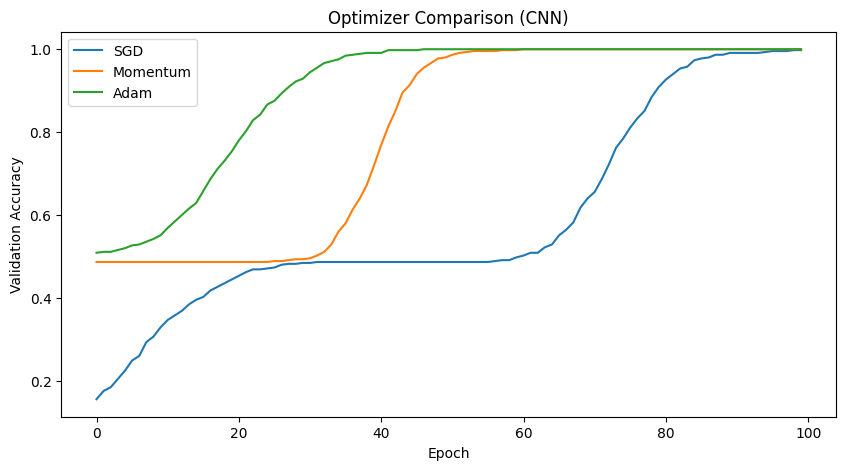

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    z=np.clip(z,-500,500)
    return 1/(1+np.exp(-z))

def relu(z):
    return np.maximum(0,z)

def bce(y,yh):
    eps=1e-8
    yh=np.clip(yh,eps,1-eps)
    return -np.mean(y*np.log(yh)+(1-y)*np.log(1-yh))

def acc(y,yh):
    return np.mean((yh>=0.5)==y)

def conv_forward(X,K):
    N,H,W=X.shape
    num_filters,F,_=K.shape
    out=np.zeros((N,num_filters,H-F+1,W-F+1))
    for n in range(N):
        for f in range(num_filters):
            for i in range(H-F+1):
                for j in range(W-F+1):
                    region=X[n,i:i+F,j:j+F]
                    out[n,f,i,j]=np.sum(region*K[f])
    return out

def pool_forward(X):
    N,C,H,W=X.shape
    out=np.zeros((N,C,H//2,W//2))
    for n in range(N):
        for c in range(C):
            for i in range(0,H,2):
                for j in range(0,W,2):
                    out[n,c,i//2,j//2]=np.max(X[n,c,i:i+2,j:j+2])
    return out

def dropout_forward(X,drop_prob):
    mask=(np.random.rand(*X.shape)>drop_prob).astype(float)
    return X*mask/(1-drop_prob),mask

def sgd(W,dW,lr):
    return W-lr*dW

def momentum(W,dW,V,lr,beta=0.9):
    V=beta*V+lr*dW
    W=W-V
    return W,V

def adam(W,dW,m,v,t,lr=0.001,b1=0.9,b2=0.999,eps=1e-8):
    m=b1*m+(1-b1)*dW
    v=b2*v+(1-b2)*(dW**2)
    m_hat=m/(1-b1**t)
    v_hat=v/(1-b2**t)
    W=W-lr*m_hat/(np.sqrt(v_hat)+eps)
    return W,m,v

def train_cnn(optimizer='sgd',epochs=100,lr=0.01):

    img_size=8
    F=3
    num_filters=4
    drop_prob=0.5

    K=np.random.randn(num_filters,F,F)*0.1
    conv_out=img_size-F+1
    pool_out=conv_out//2
    flat_size=num_filters*pool_out*pool_out

    W=np.random.randn(flat_size,1)*0.1
    b=np.zeros((1,1))

    V=np.zeros_like(W)
    m=np.zeros_like(W)
    v=np.zeros_like(W)

    history={'train_acc':[],'val_acc':[],'test_acc':[],'val_loss':[]}

    for t in range(1,epochs+1):

        conv=conv_forward(X_train,K)
        rel=relu(conv)
        pool=pool_forward(rel)
        flat=pool.reshape(len(pool),-1)
        flat,_=dropout_forward(flat,drop_prob)

        Z=flat@W+b
        A=sigmoid(Z)

        dZ=A-y_train
        dW=flat.T@dZ/len(flat)
        db=np.mean(dZ,axis=0,keepdims=True)

        if optimizer=='sgd':
            W=sgd(W,dW,lr)
        elif optimizer=='momentum':
            W,V=momentum(W,dW,V,lr)
        elif optimizer=='adam':
            W,m,v=adam(W,dW,m,v,t,lr=0.001)

        b-=lr*db

        conv_v=conv_forward(X_val,K)
        rel_v=relu(conv_v)
        pool_v=pool_forward(rel_v)
        flat_v=pool_v.reshape(len(pool_v),-1)
        A_v=sigmoid(flat_v@W+b)

        # ---- TEST ----
        conv_t=conv_forward(X_test,K)
        rel_t=relu(conv_t)
        pool_t=pool_forward(rel_t)
        flat_t=pool_t.reshape(len(pool_t),-1)
        A_t=sigmoid(flat_t@W+b)

        history['train_acc'].append(acc(y_train,A))
        history['val_acc'].append(acc(y_val,A_v))
        history['test_acc'].append(acc(y_test,A_t))
        history['val_loss'].append(bce(y_val,A_v))

    return history

hist_sgd=train_cnn('sgd')
hist_momentum=train_cnn('momentum')
hist_adam=train_cnn('adam')

print("Final Test Accuracy")
print("SGD:",hist_sgd['test_acc'][-1])
print("Momentum:",hist_momentum['test_acc'][-1])
print("Adam:",hist_adam['test_acc'][-1])

plt.figure(figsize=(10,5))
plt.plot(hist_sgd['val_acc'],label='SGD')
plt.plot(hist_momentum['val_acc'],label='Momentum')
plt.plot(hist_adam['val_acc'],label='Adam')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison (CNN)")
plt.legend()
plt.show()